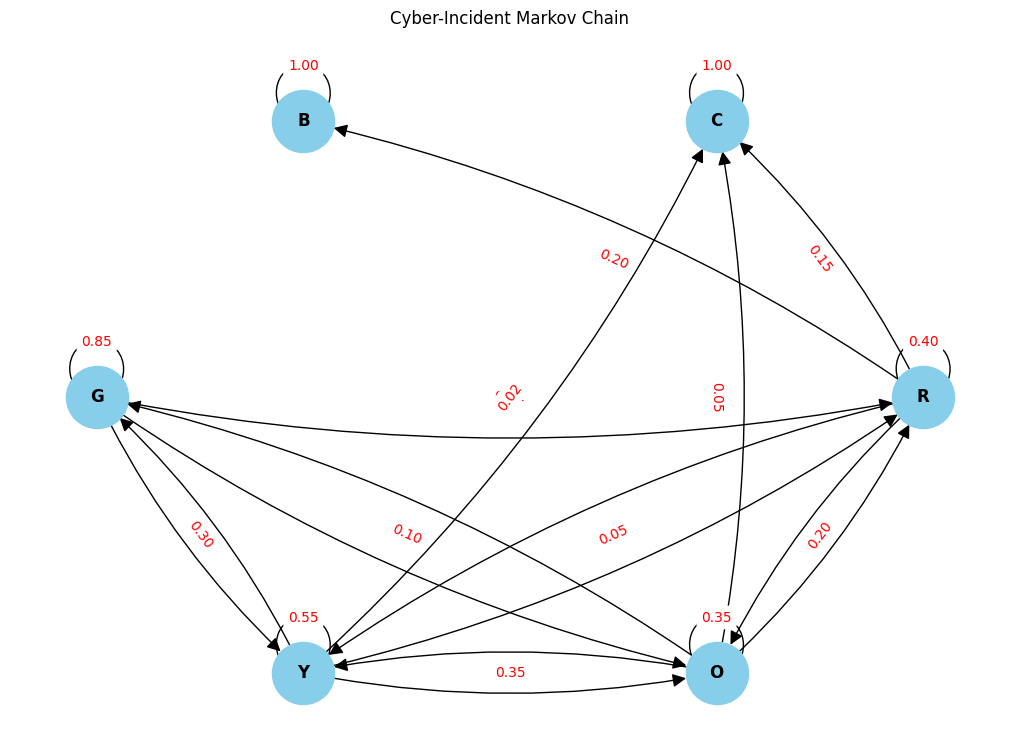

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Define states and Matrix P
states = ["G", "Y", "O", "R", "C", "B"]
P = np.array([
    [0.85, 0.12, 0.02, 0.01, 0.00, 0.00], 
    [0.30, 0.55, 0.10, 0.03, 0.02, 0.00], 
    [0.10, 0.35, 0.35, 0.15, 0.05, 0.00], 
    [0.00, 0.05, 0.20, 0.40, 0.15, 0.20], 
    [0.00, 0.00, 0.00, 0.00, 1.00, 0.00], 
    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00]  
])
# Define the Cost Vectors
c = np.array([0.0, 0.2, 1.0, 5.0]) # Running costs for [G, Y, O, R] in Lakhs/hr
g = np.array([25, 300])            # Terminal costs for [C, B] in Lakhs
# Create a Directed Graph
G = nx.DiGraph()

# Add nodes and edges only if probability > 0
for i, origin in enumerate(states):
    for j, destination in enumerate(states):
        prob = P[i, j]
        if prob > 0:
            G.add_edge(origin, destination, weight=prob)

# Draw the graph
plt.figure(figsize=(10, 7))
pos = nx.shell_layout(G) # Better layout for showing flow

nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', 
        font_size=12, font_weight='bold', arrowsize=20, connectionstyle='arc3, rad = 0.1')

# Add edge labels (probabilities)
edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Cyber-Incident Markov Chain")
plt.show()

In [2]:
# 1. Extract Q (Transient to Transient)
# Rows 0-3 (G, Y, O, R), Columns 0-3 (G, Y, O, R)
Q = P[0:4, 0:4]

# 2. Extract R (Transient to Absorbing)
# Rows 0-3 (G, Y, O, R), Columns 4-5 (C, B)
R = P[0:4, 4:6]

# 3. Create Identity Matrix for Transient States
I = np.eye(4)

# 4. Calculate Fundamental Matrix N = (I - Q)^-1
N = np.linalg.inv(I - Q)
E_T = np.sum(N, axis=1)
# 5. Calculate Committor Probabilities B_probs = N * R
B_probs = np.dot(N, R)

# --- Extracting the Answers ---
# Our starting state is 'Y' (Yellow).
# In our transient list [G, Y, O, R], 'Y' is at index 1.
start_state_index = 1 

# In our absorbing list [C, B], 'C' is index 0, 'B' is index 1.
index_C = 0
index_B = 1

# Task 2(a): P(hit B before C) starting from Y
prob_B_first = B_probs[start_state_index, index_B]

# Task 2(b): P(hit C before B) starting from Y
prob_C_first = B_probs[start_state_index, index_C]

print(f"Committor for B (Hit B before C): {prob_B_first:.4f}")
print(f"Committor for C (Hit C before B): {prob_C_first:.4f}")
print(f"Verification (Sum): {prob_B_first + prob_C_first:.4f}")
print(f"Expected time to absorption starting from Y: {E_T[1]:.2f} hours\n")

Committor for B (Hit B before C): 0.3522
Committor for C (Hit C before B): 0.6478
Verification (Sum): 1.0000
Expected time to absorption starting from Y: 41.35 hours



In [3]:
f_t = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0])

# Run the recursion 24 times
for t in range(24):
    # f_t(y) = sum_x P(y,x) * f_{t-1}(x)
    f_t = np.dot(P, f_t) 

# Start state is Yellow (index 1)
recursive_prob = f_t[1]

# ---------------------------------------------------------
# Method 2: The standard Matrix Power approach
# ---------------------------------------------------------
v0 = np.array([0, 1, 0, 0, 0, 0]) # Start 100% in Y
P24 = np.linalg.matrix_power(P, 24)
matrix_prob = np.dot(v0, P24)[5] # Index 5 is B

print(f"Prob from your recursion: {recursive_prob:.6f}")
print(f"Prob from matrix power:   {matrix_prob:.6f}")

Prob from your recursion: 0.152869
Prob from matrix power:   0.152869


In [4]:
start_idx = 1
expected_running_cost = np.dot(N[start_idx, :], c)